# Analyzing attack experiment

## What is this 'notebook'?
This is a Jupyter Notebook. It is a tool that allows us to write and execute code in an interactive way. We can also add text, images, and other media to explain what we are doing. This makes it a great tool for data analysis and visualization. In this notebook, we will use Python to analyze the finger-tapping data that we collected during the experiment.

---

In this environment, you can run the code cells by clicking on them and pressing Shift + Enter. You can also edit the code and run it again to see how it works. Don't worry about making mistakes, that's part of the learning process! You can always go back to the original code by clicking File > Revert Notebook to Checkpoint.

---

Enjoy! Don't worry about understanding everything (especially not the code of course). If you're interested, and if you have any questions, feel free to ask (jelle.vanderwerff \[at\] uniroma1.it).

## First step: Loading the libraries that we will use

Below, we use all the so-called 'libraries' that we will need for our analysis. A library is a collection of pre-written code that we can use to perform specific tasks. For example, the `pandas` library is great for working with data in tables, and the `seaborn` library is great for creating beautiful visualizations. By importing these libraries at the beginning of our notebook, we can use their functions and features throughout our analysis.

Run the cell below by putton your cursor in the cell and pressing Shift + Enter. This will load all the libraries that we need for our analysis.

In [32]:
# Install packages
%pip install pandas numpy matplotlib seaborn statsmodels

# Importing 'packages'
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define constants
TRIAL_CONDITIONS = [50, 150, 0, 100, 200]
STIMULUS_INTERVAL = 0.5
N_INTERVALS = 24
STIMULUS_ONSETS = np.cumsum([0] + [STIMULUS_INTERVAL] * N_INTERVALS)[:-1]


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Recap of the experiment
The experiment looked like this:

![experiment](experiment_design.png)

There were 5 conditions, where **the attack of the stimulus was either 0, 50, 100, 150, or 200 ms** (referred to as ``trial_condition`` in all the plots below).

The participants had to tap along with the stimulus, and we recorded their tapping behavior (onsets and velocities).

## Data pre-processing

The data that comes out of the experiment is in a raw format (and a bit of a mess). We need to process it to make it usable for analysis. This involves several steps, such as cleaning the data, extracting relevant features, and organizing it in a way that we can easily analyze.

---

Below we first load the data from the experiment, and then save them in a more usable format (CSV files). We will also do some basic cleaning to prepare the data for analysis. Note that first we start with the **onsets** data (and then later we will do the inter-onset intervals, or IOIs). We also save the onsets of the stimulus.

*Please don't worry about the code below; it's a bit technical, but it's just a way to automate the data processing. The important thing is that we end up with clean and organized data that we can analyze later on.*

In [55]:
# Create an empty table (DataFrame) where we will store all processed onset data
onsets = pd.DataFrame()

# Get all CSV files in the ./data folder
# Each CSV file is one participant/session export from the experiment
filenames = [file for file in os.listdir('./data') if file.endswith('.csv')]

# Loop through each participant file
for file in filenames:
    # Read one CSV file into a DataFrame
    df_response = pd.read_csv(os.path.join('./data', file))

    # Participant ID (same for all rows in one file)
    pp_id = df_response.participant[0]

    # Group rows by trial (each sound file/trial separately)
    for trial, trial_df in df_response.groupby('fileName'):
        # Time when the stimulus started (this is our zero point for the trial)
        stimulus_t_zero = trial_df["stimulus.started"].dropna().values[0]

        # Raw tap times (absolute clock time), remove missing values
        resp_onsets_t = trial_df["resp.time"].dropna().values

        # Convert absolute tap times to "seconds since stimulus start"
        # Example: if a tap happened 1.2s after stimulus start, onset = 1.2
        resp_onsets = resp_onsets_t - stimulus_t_zero

        # Remove taps that are outside the trial window:
        # - before stimulus starts (< 0)
        # - after trial ends (> 15 seconds)
        resp_onsets_wrong_indices = np.where((resp_onsets < 0) | (resp_onsets > 15))[0]
        resp_onsets = np.delete(resp_onsets, resp_onsets_wrong_indices)

        # Get tap velocity values and remove entries that match removed taps
        resp_velocity = trial_df["resp.velocity"].dropna().values
        resp_velocity = np.delete(resp_velocity, resp_onsets_wrong_indices)

        # For each tap, find the closest expected stimulus onset.
        # This is used to compute "tap location":
        # tap_location = (actual tap time) - (closest stimulus beat time)
        closest_stim_onsets = [
            STIMULUS_ONSETS[np.argmin(np.abs(resp_onset - STIMULUS_ONSETS))]
            for resp_onset in resp_onsets
        ]
        tap_location = np.array(resp_onsets) - np.array(closest_stim_onsets)

        # Add rows to table
        onsets = pd.concat([
            onsets,
            pd.DataFrame({
                'pp_id': pp_id,
                'trial_condition': trial.split('_')[-1].strip('ms.wav'),
                'onset_i': np.arange(len(resp_onsets)) + 1,
                'resp_onset': resp_onsets,
                'tap_location': tap_location,
                'velocity': resp_velocity
            })
        ]).reset_index(drop=True)

# Convert trial_condition from text to integer (e.g., "50" -> 50)
onsets['trial_condition'] = onsets['trial_condition'].astype(int)

# Sort rows so the table is easy to read and consistent for later analysis
onsets = onsets.sort_values(
    by=['pp_id', 'trial_condition', 'onset_i']
).reset_index(drop=True)

# Save processed output to CSV so later cells can load/use it directly
onsets.to_csv(os.path.join(".", "data", "processed", "onsets.csv"), index=False)

If want to take a quick look at the data, we can use the `head()` function to see the first few rows of the dataframes. This can give us a sense of what the data looks like and what kind of information it contains.

We can also use the `describe()` function to get a summary of the data (averages, standard deviations, etc.).

In [56]:
onsets.head(30)

,pp_id,trial_condition,onset_i,resp_onset,tap_location,velocity
0,jelle,0,1,1.196049,0.196049,93.0
1,jelle,0,2,1.621170,0.121170,92.0
2,jelle,0,3,1.958071,-0.041929,71.0
3,jelle,0,4,2.275350,-0.224650,37.0
4,jelle,0,5,2.508709,0.008709,116.0
5,jelle,0,6,3.008816,0.008816,55.0
6,jelle,0,7,3.516762,0.016762,74.0
7,jelle,0,8,4.000715,0.000715,71.0
8,jelle,0,9,4.525138,0.025138,101.0
9,jelle,0,10,5.067000,0.067000,64.0


--- 

Maybe here take a pause: What do you think all the columns mean?

---

Let's describe the data. In the summary table:

- **`count`**: the number of rows or values included
- **`mean`**: the average value
- **`std`**: the standard deviation, which shows how spread out the values are
- **`min`**: the smallest value
- **`25%`**: the 25th percentile, meaning 25% of the values are below this point
- **`50%`**: the median, meaning 50% of the values are below this point
- **`75%`**: the 75th percentile, meaning 75% of the values are below this point
- **`max`**: the largest value

In [57]:
onsets.describe()

,trial_condition,onset_i,resp_onset,tap_location,velocity
count,276.000000,276.000000,276.000000,276.000000,276.000000
mean,85.362319,12.010870,6.158113,0.027678,63.297101
std,71.173636,6.664142,3.381947,0.145932,21.033621
min,0.000000,1.000000,0.000282,-0.249884,17.000000
25%,20.000000,6.000000,3.241276,-0.026207,47.000000
50%,50.000000,12.000000,6.131284,0.033970,59.000000
75%,150.000000,18.000000,9.044007,0.120790,80.000000
max,200.000000,24.000000,12.001940,0.501940,118.000000


## Inter-onset intervals

We also make a new dataframe to for the inter-onset intervals (IOIs). We calculate the IOIs by taking the difference between consecutive onsets. After all, the IOIs are just the time intervals between taps, so we can calculate them by taking the difference between onsets that happened in a row (consecutively).

In [59]:
# Create an empty table where we will store all IOI rows
# IOI = Inter-Onset Interval = time between two consecutive taps
iois = pd.DataFrame()

# Split by participant
for pp_id, pp_df in onsets.groupby('pp_id'):

    # For each participant, split data by trial condition (0, 50, 100, 150, 200) ms attack
    for trial_condition, trial_df in pp_df.groupby('trial_condition'):

        # Extract the onset times (tap times) for this participant and condition
        trial_onsets = trial_df['resp_onset'].values

        # np.diff computes differences between consecutive values:
        # [t1, t2, t3] -> [t2-t1, t3-t2]
        # These differences are the IOIs
        iois_trial = np.diff(trial_onsets)

        # Build a small dataframe for this one participant + condition
        # ioi_i = position of the IOI in the sequence (1st interval, 2nd interval, ...)
        iois_one_trial = pd.DataFrame({
            'pp_id': pp_id,
            'trial_condition': trial_condition,
            'ioi_i': np.arange(len(iois_trial)) + 1,
            'ioi': iois_trial
        })

        # Add these rows to the full IOI dataframe
        iois = pd.concat([iois, iois_one_trial]).reset_index(drop=True)

Again, we can can take a quick look at the IOI data using the `head()` and `describe()` functions to get a sense of what the data looks like and to check for any issues.
Now you can type the ``iois.head()`` and ``iois.describe()`` commands to take a look at the IOI data, use the empty cell below:

## Plotting the data

The first step to any data analysis is to visualize the data. For us, because I don't want to bore you with statistics, this is also our final goal.

Plots help us understand the data better and identify any patterns or trends. We can use various plotting libraries in Python, such as Matplotlib and Seaborn, to create different types of plots. Remember that now we have two *dataframes*: one for the onsets and one for the IOIs. 

We can plot both of them to see how they look.

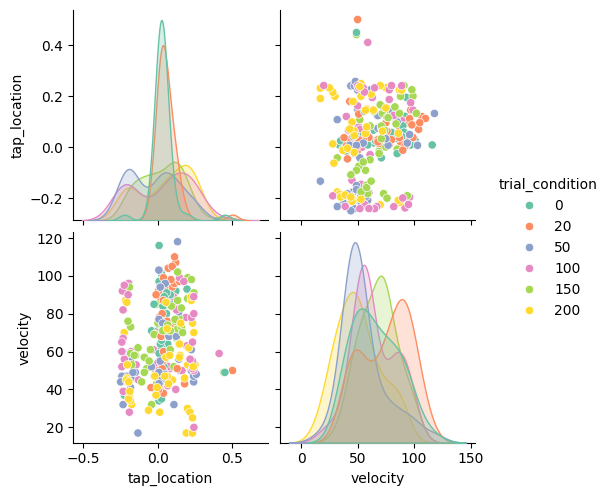

In [60]:
# plot the timing of the onset (relative to the stimulus) and the velocity of the response, colored by trial condition
p = sns.pairplot(onsets, hue="trial_condition", vars=["tap_location", "velocity"], palette="Set2")

While we may already see some patterns, in this kind of plot it's not so clear, below we plot the data in a different way, to make it easier to see the patterns.

### Tap location by trial condition (i.e. amount of attack)
Does the location of the tap change with the amount of attack? The onset values as recorded here are relative to the onset of the sound.
So, if a person taps for instance 20 milliseconds after the sound starts, the onset value will be 20. If they tap before the sound starts, the onset value will be negative (e.g. -10 if they tap 10 milliseconds before the sound starts). We can plot the onsets for each trial condition (i.e. each level of attack) to see if there are any differences in tap location.

To do so, we use 'probability density plots' (or KDE plots) to visualize the distribution of tap locations for each trial condition. Probability density plots
are basically smoothed out histograms that show the distribution of a continuous variable (in this case, the onsets). If the resulting plot shows that the distribution of onsets is different for different trial conditions, this could suggest that the amount of attack affects the tap location. For example, if we see that the distribution of onsets is more spread out for higher levels of attack, this could indicate that participants are tapping more variably in response to stronger attacks (this is what they called 'beat bin' in Danielsen et al., 2024). On the other hand, if the distribution of onsets is similar across trial conditions, this could suggest that the amount of attack does not affect the tap location.

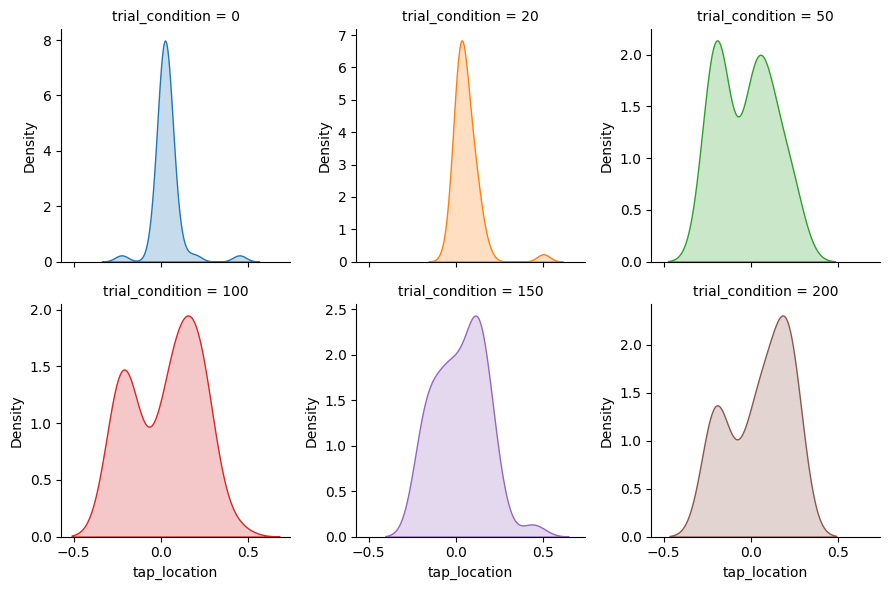

In [61]:
# We create a grid onto which to plot
g = sns.FacetGrid(onsets, col="trial_condition", hue="trial_condition", col_wrap=3, sharex=True, sharey=False)

# Then we plot the 'probability density', here called kde, of the onsets for each trial condition (i.e. each level of attack)
g.map(sns.kdeplot, "tap_location", fill=True)

What do you see in this plot? Are the tapping locations different across trial conditions?

### Tapping precision by condition

Remember the difference between tapping precision and tapping accuracy? Tapping precision refers to how consistent the tapping is, while tapping accuracy refers to how close the taps are to the stimulus onsets. If you are consistently wrong, but always wrong in the same way, you are precise but not accurate.

If we want to see how *consistently* participants tap across conditions, we can look at the inter-onset intervals (IOIs). The IOIs are the time intervals between consecutive taps, so they can give us an indication of how regular or irregular the tapping is. We can plot the IOIs for each trial condition to see if there are any differences in tapping precision.

### Tapping variability by position in the sequence
Generally, when people tap along with a sequence of sounds, their tapping tends to be more variable at the beginning of the sequence and becomes more stable as they get into the groove. This is because it takes some time for people to synchronize their tapping with the sounds, and once they are in sync, their tapping becomes more consistent. We can plot the variability of tapping by using boxplots. The wider/longer the box, the more variable the tapping is. If we see that the boxes are longer at the beginning of the sequence and become shorter towards the end, this would suggest that tapping variability decreases as people get into the groove.

/Users/jellevanderwerff/.pyenv/versions/3.11.13/lib/python3.11/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


Text(0.5, 1.02, 'IOI by trial condition')

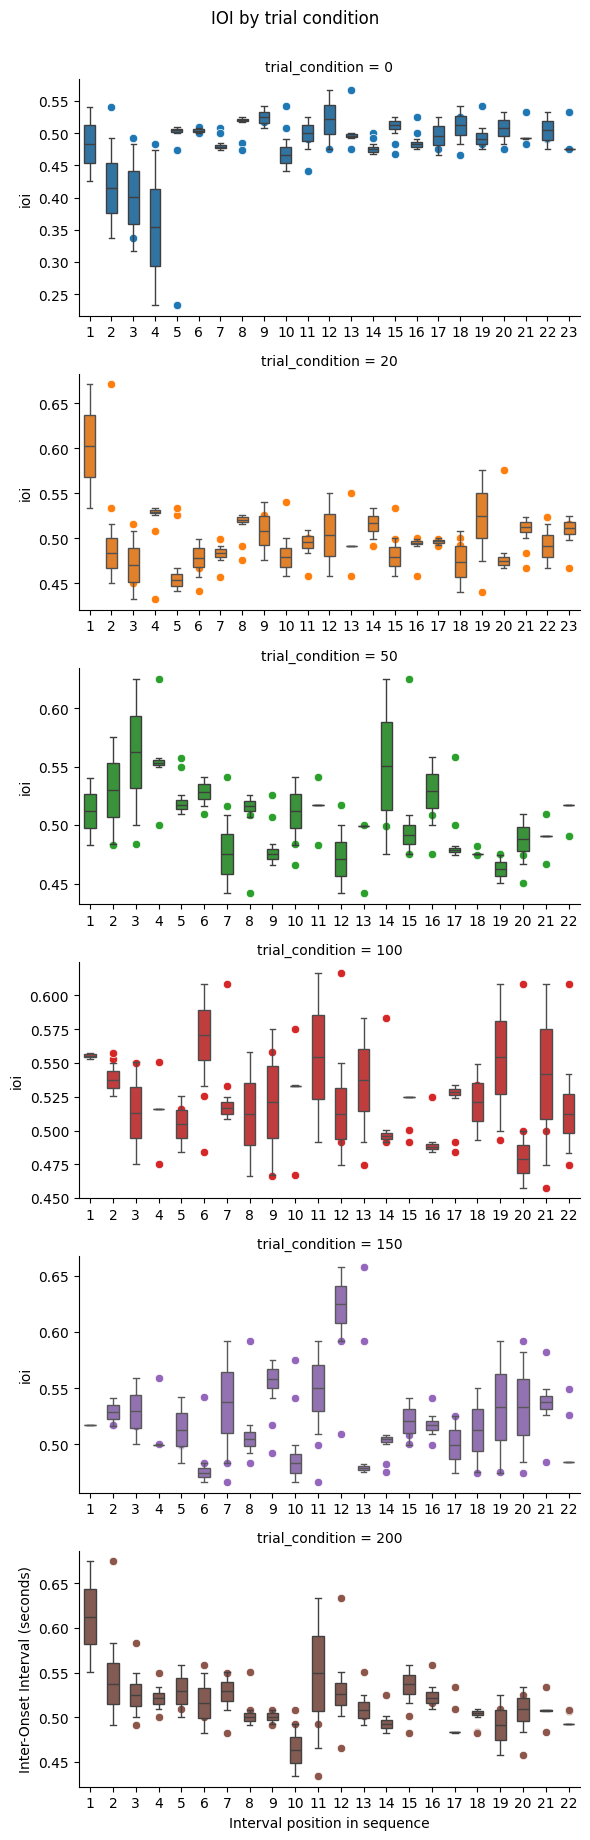

In [67]:
# Create a grid for plotting
g = sns.FacetGrid(iois, col="trial_condition", hue="trial_condition", col_wrap=1, sharex=False, sharey=False, aspect=2)
# Plot scatters and boxplots of IOIs for each trial condition
g.map(sns.scatterplot, "ioi_i", "ioi")
g.map(sns.boxplot, "ioi_i", "ioi", showfliers=False, width=0.5)
plt.xlabel("Interval position in sequence")
plt.ylabel("Inter-Onset Interval (seconds)")
plt.suptitle("IOI by trial condition", y=1.02)

What do you see here? Do you see a decrease in tapping variability as the sequence progresses? Are there any differences in this pattern across trial conditions (i.e. different levels of attack)? As a hint, the amount of variability is given by the spread of the points in the scatterplot, and by the size of the boxes in the boxplot. If you see that the points are more spread out and the boxes are larger at the beginning of the sequence, this could indicate that tapping is more variable at the beginning. If you see that the points become less spread out and the boxes become smaller as the sequence progresses, this could indicate that tapping becomes more stable as people get into the groove.

### Thanks!
I've bored (or maybe not) you with a lot of code, but I hope it was interesting to see how we can analyze the data from our experiment. If you have any questions about the code or the analysis, feel free to ask! Happy Easter and see you in the next workshop!

---

Jelle van der Werff